# Phase Quantum Walk — Graph State Distribution Protocols

**M.Tech Thesis — IIT Jodhpur**  
**Author:** Soumyojyoti Dutta (M24IQT014)

---

## Overview

Implements and verifies the **phase quantum walk** protocol for distributing
eight distinct graph states across spatially separated parties.
All protocols share the same 4-stage architecture; only the graph topology
(and hence the shift connections in Stage 3) differs.

| # | Protocol | Graph | Edges | Res. qubits | Total qubits | Outcomes |
|:-:|:--------:|:-----:|:-----:|:-----------:|:------------:|:--------:|
| 1 | GHZ₄     | Star K₁,₃ | 3 | 6  | 10 | 64   |
| 2 | \|L₄⟩    | Path P₄   | 3 | 6  | 10 | 64   |
| 3 | \|C₄⟩    | Ring C₄   | 4 | 8  | 12 | 256  |
| 4 | \|L₅⟩    | Path P₅   | 4 | 8  | 13 | 256  |
| 5 | \|K₄⟩    | Complete K₄ | 6 | 12 | 16 | 4096 |
| 6 | \|C₅⟩    | Ring C₅   | 5 | 10 | 15 | 1024 |
| 7 | \|K₁,₄⟩  | Star K₁,₄ | 4 | 8  | 13 | 256  |
| 8 | Bull     | Bull graph | 5 | 10 | 15 | 1024 |

**Protocol stages (same for all topologies):**
```
Stage 1:  H on each data qubit
Stage 2:  H⊗H then CZ on each resource pair  →  |G_K2> = CZ|++>
Stage 3:  CZ(data, resource) per edge-end     →  phase walk
Stage 4:  H on all resource qubits            →  measure in Z basis
Feed-forward: local Pauli corrections based on outcomes
```

## 1. Imports and Primitives

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
from itertools import product as iproduct
import matplotlib.pyplot as plt
%matplotlib inline

I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]],  dtype=complex)
Y  = np.array([[0,-1j],[1j,0]],dtype=complex)
Z  = np.array([[1,0],[0,-1]], dtype=complex)
H2 = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)

def gaten(G, qubit, n):
    """Embed single-qubit gate G on `qubit` in an n-qubit Qiskit little-endian tensor."""
    ops = [I2] * n
    ops[n - 1 - qubit] = G
    result = ops[0]
    for o in ops[1:]: result = np.kron(result, o)
    return result

print('Imports OK.')

Imports OK.


## 2. Target States (all 8 graphs)

In [2]:
def make_graph_state(n, edges):
    """Build graph state |G> = prod_{(i,j) in E} CZ_ij |+>^n via Qiskit."""
    qc = QuantumCircuit(n)
    qc.h(list(range(n)))
    for i, j in edges:
        qc.cz(i, j)
    return Statevector(qc)

TARGETS = {
    'GHZ4':  make_graph_state(4, [(0,1),(0,2),(0,3)]),           # star K1,3
    'L4':    make_graph_state(4, [(0,1),(1,2),(2,3)]),            # path P4
    'C4':    make_graph_state(4, [(0,1),(1,2),(2,3),(3,0)]),      # ring C4
    'L5':    make_graph_state(5, [(0,1),(1,2),(2,3),(3,4)]),      # path P5
    'K4':    make_graph_state(4, [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]),  # complete
    'C5':    make_graph_state(5, [(0,1),(1,2),(2,3),(3,4),(4,0)]),# ring C5
    'K14':   make_graph_state(5, [(0,1),(0,2),(0,3),(0,4)]),      # star K1,4
    'Bull':  make_graph_state(5, [(0,1),(1,2),(0,2),(0,3),(2,4)]),# bull graph
}

for name, sv in TARGETS.items():
    print(f'  {name:6s}: {sv.data.shape}  norm={np.linalg.norm(sv.data):.10f}')

  GHZ4  : (16,)  norm=1.0000000000
  L4    : (16,)  norm=1.0000000000
  C4    : (16,)  norm=1.0000000000
  L5    : (32,)  norm=1.0000000000
  K4    : (16,)  norm=1.0000000000
  C5    : (32,)  norm=1.0000000000
  K14   : (32,)  norm=1.0000000000
  Bull  : (32,)  norm=1.0000000000


## 3. Stabiliser Eigenvalue Check

For each graph state |G>, verify all stabiliser generators g_v = X_v ⊗_{u~v} Z_u.

In [3]:
def check_stabilisers(sv, n, edges):
    """Verify all n stabiliser generators for graph state on n qubits."""
    adj = {v: [] for v in range(n)}
    for i, j in edges:
        adj[i].append(j); adj[j].append(i)
    all_ok = True
    for v in range(n):
        ops = [I2] * n
        ops[n-1-v] = X
        for u in adj[v]: ops[n-1-u] = Z
        S = ops[0]
        for o in ops[1:]: S = np.kron(S, o)
        ev = float(np.real(np.vdot(sv.data, S @ sv.data)))
        ok = abs(ev - 1.0) < 1e-8
        if not ok: print(f'    FAIL: g_{v} = {ev:.8f}'); all_ok = False
    return all_ok

GRAPH_EDGES = {
    'GHZ4': [(0,1),(0,2),(0,3)],
    'L4':   [(0,1),(1,2),(2,3)],
    'C4':   [(0,1),(1,2),(2,3),(3,0)],
    'L5':   [(0,1),(1,2),(2,3),(3,4)],
    'K4':   [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)],
    'C5':   [(0,1),(1,2),(2,3),(3,4),(4,0)],
    'K14':  [(0,1),(0,2),(0,3),(0,4)],
    'Bull': [(0,1),(1,2),(0,2),(0,3),(2,4)],
}
N_DATA = {'GHZ4':4,'L4':4,'C4':4,'L5':5,'K4':4,'C5':5,'K14':5,'Bull':5}

print('Stabiliser eigenvalue checks:')
for name in TARGETS:
    ok = check_stabilisers(TARGETS[name], N_DATA[name], GRAPH_EDGES[name])
    print(f'  {name:6s}: {"✓ all +1" if ok else "✗ FAILED"}')

Stabiliser eigenvalue checks:
  GHZ4  : ✓ all +1
  L4    : ✓ all +1
  C4    : ✓ all +1
  L5    : ✓ all +1
  K4    : ✓ all +1
  C5    : ✓ all +1
  K14   : ✓ all +1
  Bull  : ✓ all +1


## 4. Protocol Circuits

Each circuit follows the same 4-stage architecture. The only difference per
topology is the **walk pairs** in Stage 3 — which (data qubit, resource qubit)
pairs receive CZ gates, determined by the graph edge structure.

### GHZ4 — Star K₁,₃ (10 qubits, 3 edges)

In [4]:
# GHZ4 — Star K1,3
# Layout:  q0=hub  q1,q2=res_AB(s1,s2)  q3=leaf-B  q4,q5=res_AC(s3,s4)
#          q6=leaf-C  q7,q8=res_AD(s5,s6)  q9=leaf-D
# Walk:  CZ(hub,near) and CZ(leaf,far) per edge
def build_GHZ4():
    qc = QuantumCircuit(10, name='GHZ4')
    qc.h([0,3,6,9]);              qc.barrier(label='S1')
    qc.h([1,2]); qc.cz(1,2)
    qc.h([4,5]); qc.cz(4,5)
    qc.h([7,8]); qc.cz(7,8);     qc.barrier(label='S2')
    qc.cz(0,1);  qc.cz(3,2)      # edge hub-B
    qc.cz(0,4);  qc.cz(6,5)      # edge hub-C
    qc.cz(0,7);  qc.cz(9,8);     qc.barrier(label='S3')
    qc.h([1,2,4,5,7,8])
    return qc

qc_GHZ4 = build_GHZ4()
print(f'GHZ4: {qc_GHZ4.num_qubits} qubits | depth={qc_GHZ4.depth()} | {dict(qc_GHZ4.count_ops())}')

GHZ4: 10 qubits | depth=7 | {'h': 16, 'cz': 9, 'barrier': 3}


### L4 — Path P₄ (10 qubits, 3 edges)

In [5]:
# L4 — Path P4  (A-B-C-D)
# Layout:  q0=A  q1,q2=res_AB(s1,s2)  q3=B  q4,q5=res_BC(s3,s4)
#          q6=C  q7,q8=res_CD(s5,s6)  q9=D
def build_L4():
    qc = QuantumCircuit(10, name='L4')
    qc.h([0,3,6,9]);              qc.barrier(label='S1')
    qc.h([1,2]); qc.cz(1,2)
    qc.h([4,5]); qc.cz(4,5)
    qc.h([7,8]); qc.cz(7,8);     qc.barrier(label='S2')
    qc.cz(0,1);  qc.cz(3,2)      # edge A-B
    qc.cz(3,4);  qc.cz(6,5)      # edge B-C
    qc.cz(6,7);  qc.cz(9,8);     qc.barrier(label='S3')
    qc.h([1,2,4,5,7,8])
    return qc

qc_L4 = build_L4()
print(f'L4: {qc_L4.num_qubits} qubits | depth={qc_L4.depth()} | {dict(qc_L4.count_ops())}')

L4: 10 qubits | depth=6 | {'h': 16, 'cz': 9, 'barrier': 3}


### C4 — Ring C₄ (12 qubits, 4 edges)

In [6]:
# C4 — Ring C4  (A-B-C-D-A)
# Layout:  q0=A  q1,q2=res_AB(s1,s2)   q3=B  q4,q5=res_BC(s3,s4)
#          q6=C  q7,q8=res_CD(s5,s6)   q9=D  q10,q11=res_DA(s7,s8)
def build_C4():
    qc = QuantumCircuit(12, name='C4')
    qc.h([0,3,6,9]);               qc.barrier(label='S1')
    qc.h([1,2]);   qc.cz(1,2)
    qc.h([4,5]);   qc.cz(4,5)
    qc.h([7,8]);   qc.cz(7,8)
    qc.h([10,11]); qc.cz(10,11);   qc.barrier(label='S2')
    qc.cz(0,1);  qc.cz(3,2)        # edge A-B
    qc.cz(3,4);  qc.cz(6,5)        # edge B-C
    qc.cz(6,7);  qc.cz(9,8)        # edge C-D
    qc.cz(9,10); qc.cz(0,11);      qc.barrier(label='S3')
    qc.h([1,2,4,5,7,8,10,11])
    return qc

qc_C4 = build_C4()
print(f'C4: {qc_C4.num_qubits} qubits | depth={qc_C4.depth()} | {dict(qc_C4.count_ops())}')

C4: 12 qubits | depth=6 | {'h': 20, 'cz': 12, 'barrier': 3}


### L5 — Path P₅ (13 qubits, 4 edges)

In [7]:
# L5 — Path P5  (A-B-C-D-E)
# Layout:  q0=A  q1,q2=res_AB(s1,s2)    q3=B  q4,q5=res_BC(s3,s4)
#          q6=C  q7,q8=res_CD(s5,s6)    q9=D  q10,q11=res_DE(s7,s8)
#          q12=E
def build_L5():
    qc = QuantumCircuit(13, name='L5')
    qc.h([0,3,6,9,12]);            qc.barrier(label='S1')
    qc.h([1,2]);   qc.cz(1,2)
    qc.h([4,5]);   qc.cz(4,5)
    qc.h([7,8]);   qc.cz(7,8)
    qc.h([10,11]); qc.cz(10,11);   qc.barrier(label='S2')
    qc.cz(0,1);   qc.cz(3,2)       # edge A-B
    qc.cz(3,4);   qc.cz(6,5)       # edge B-C
    qc.cz(6,7);   qc.cz(9,8)       # edge C-D
    qc.cz(9,10);  qc.cz(12,11);    qc.barrier(label='S3')
    qc.h([1,2,4,5,7,8,10,11])
    return qc

qc_L5 = build_L5()
print(f'L5: {qc_L5.num_qubits} qubits | depth={qc_L5.depth()} | {dict(qc_L5.count_ops())}')

L5: 13 qubits | depth=6 | {'h': 21, 'cz': 12, 'barrier': 3}


### K4 — Complete Graph (16 qubits, 6 edges)

In [8]:
# K4 — Complete graph  (all 4 nodes mutually connected)
# Layout:  q0=N0  q1,q2=res_01(s1,s2)    q3=N1  q4,q5=res_12(s3,s4)
#          q6=N2  q7,q8=res_23(s5,s6)    q9=N3
#          q10,q11=res_02(s7,s8)  q12,q13=res_03(s9,s10)  q14,q15=res_13(s11,s12)
def build_K4():
    qc = QuantumCircuit(16, name='K4')
    qc.h([0,3,6,9]);               qc.barrier(label='S1')
    for q1,q2 in [(1,2),(4,5),(7,8),(10,11),(12,13),(14,15)]:
        qc.h([q1,q2]); qc.cz(q1,q2)
    qc.barrier(label='S2')
    qc.cz(0,1);  qc.cz(3,2)        # edge 0-1
    qc.cz(3,4);  qc.cz(6,5)        # edge 1-2
    qc.cz(6,7);  qc.cz(9,8)        # edge 2-3
    qc.cz(0,10); qc.cz(6,11)       # edge 0-2
    qc.cz(0,12); qc.cz(9,13)       # edge 0-3
    qc.cz(3,14); qc.cz(9,15);      qc.barrier(label='S3')
    qc.h([1,2,4,5,7,8,10,11,12,13,14,15])
    return qc

qc_K4 = build_K4()
print(f'K4: {qc_K4.num_qubits} qubits | depth={qc_K4.depth()} | {dict(qc_K4.count_ops())}')

K4: 16 qubits | depth=7 | {'h': 28, 'cz': 18, 'barrier': 3}


### C5 — Odd Ring C₅ (15 qubits, 5 edges)

In [9]:
# C5 — Odd cycle C5  (A-B-C-D-E-A)
# Layout:  q0=A  q1,q2=res_AB(s1,s2)    q3=B  q4,q5=res_BC(s3,s4)
#          q6=C  q7,q8=res_CD(s5,s6)    q9=D  q10,q11=res_DE(s7,s8)
#          q12=E  q13,q14=res_EA(s9,s10)
def build_C5():
    qc = QuantumCircuit(15, name='C5')
    qc.h([0,3,6,9,12]);            qc.barrier(label='S1')
    for q1,q2 in [(1,2),(4,5),(7,8),(10,11),(13,14)]:
        qc.h([q1,q2]); qc.cz(q1,q2)
    qc.barrier(label='S2')
    qc.cz(0,1);   qc.cz(3,2)       # edge A-B
    qc.cz(3,4);   qc.cz(6,5)       # edge B-C
    qc.cz(6,7);   qc.cz(9,8)       # edge C-D
    qc.cz(9,10);  qc.cz(12,11)     # edge D-E
    qc.cz(12,13); qc.cz(0,14);     qc.barrier(label='S3')
    qc.h([1,2,4,5,7,8,10,11,13,14])
    return qc

qc_C5 = build_C5()
print(f'C5: {qc_C5.num_qubits} qubits | depth={qc_C5.depth()} | {dict(qc_C5.count_ops())}')

C5: 15 qubits | depth=6 | {'h': 25, 'cz': 15, 'barrier': 3}


### K₁,₄ — Star (13 qubits, 4 edges)

In [10]:
# K1,4 — Star  (hub + 4 leaves)
# Layout:  q0=hub  q1,q2=res_01(s1,s2)  q3=L1  q4,q5=res_02(s3,s4)
#          q6=L2   q7,q8=res_03(s5,s6)  q9=L3  q10,q11=res_04(s7,s8)
#          q12=L4
def build_K14():
    qc = QuantumCircuit(13, name='K14')
    qc.h([0,3,6,9,12]);            qc.barrier(label='S1')
    for q1,q2 in [(1,2),(4,5),(7,8),(10,11)]:
        qc.h([q1,q2]); qc.cz(q1,q2)
    qc.barrier(label='S2')
    qc.cz(0,1);  qc.cz(3,2)        # edge hub-L1
    qc.cz(0,4);  qc.cz(6,5)        # edge hub-L2
    qc.cz(0,7);  qc.cz(9,8)        # edge hub-L3
    qc.cz(0,10); qc.cz(12,11);     qc.barrier(label='S3')
    qc.h([1,2,4,5,7,8,10,11])
    return qc

qc_K14 = build_K14()
print(f'K14: {qc_K14.num_qubits} qubits | depth={qc_K14.depth()} | {dict(qc_K14.count_ops())}')

K14: 13 qubits | depth=8 | {'h': 21, 'cz': 12, 'barrier': 3}


### Bull — Bull Graph (15 qubits, 5 edges)

In [11]:
# Bull graph: triangle(0,1,2) + pendant 3→0, pendant 4→2
# Edges: (0,1),(1,2),(0,2),(0,3),(2,4)
# Layout:  q0=N0  q1,q2=res_01(s1,s2)   q3=N1  q4,q5=res_12(s3,s4)
#          q6=N2  q7,q8=res_02(s5,s6)   q9=N3  q10,q11=res_03(s7,s8)
#          q12=N4  q13,q14=res_24(s9,s10)
def build_Bull():
    qc = QuantumCircuit(15, name='Bull')
    qc.h([0,3,6,9,12]);            qc.barrier(label='S1')
    for q1,q2 in [(1,2),(4,5),(7,8),(10,11),(13,14)]:
        qc.h([q1,q2]); qc.cz(q1,q2)
    qc.barrier(label='S2')
    qc.cz(0,1);  qc.cz(3,2)        # edge 0-1
    qc.cz(3,4);  qc.cz(6,5)        # edge 1-2
    qc.cz(0,7);  qc.cz(6,8)        # edge 0-2
    qc.cz(0,10); qc.cz(9,11)       # edge 0-3
    qc.cz(6,13); qc.cz(12,14);     qc.barrier(label='S3')
    qc.h([1,2,4,5,7,8,10,11,13,14])
    return qc

qc_Bull = build_Bull()
print(f'Bull: {qc_Bull.num_qubits} qubits | depth={qc_Bull.depth()} | {dict(qc_Bull.count_ops())}')

Bull: 15 qubits | depth=7 | {'h': 25, 'cz': 15, 'barrier': 3}


## 5. Circuit Diagrams

Each circuit is drawn individually. Stage barriers are labelled S1–S3.

#### GHZ4

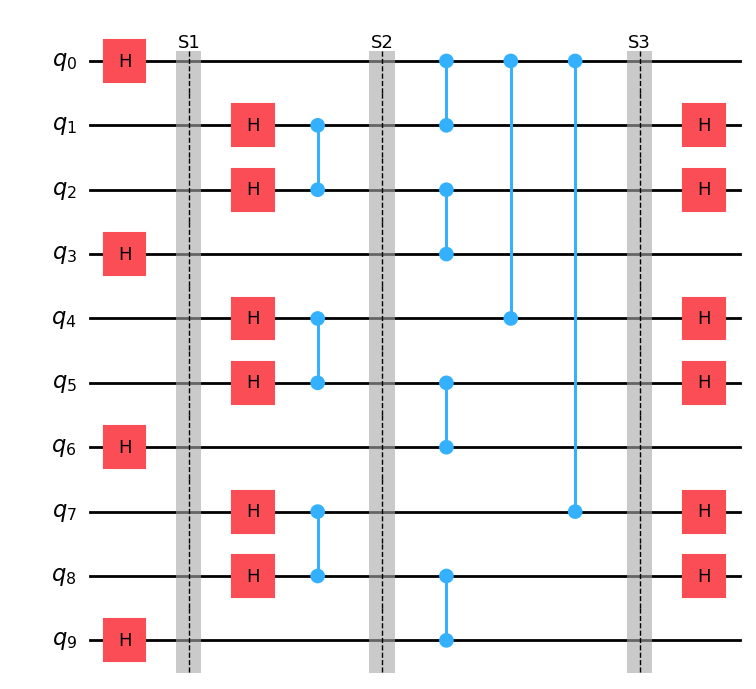

In [12]:
qc_GHZ4.draw(output='mpl', fold=50, style='iqp')

#### L4

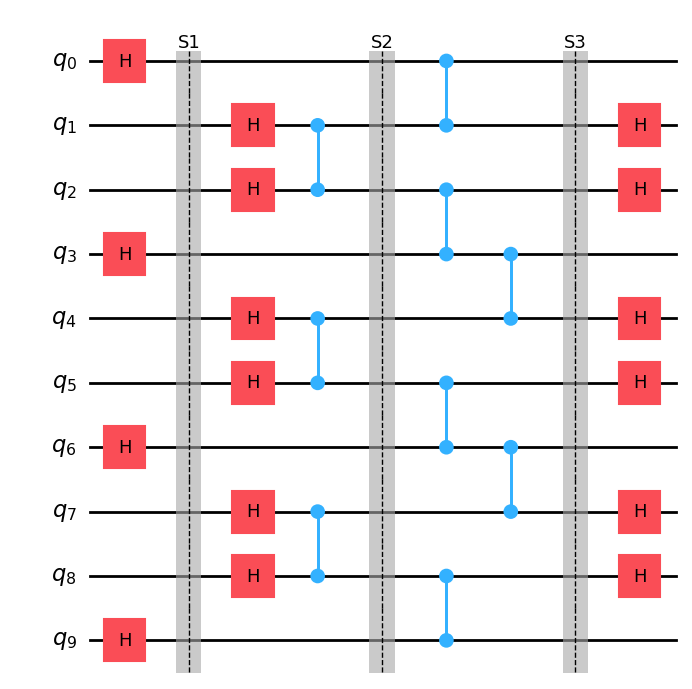

In [13]:
qc_L4.draw(output='mpl', fold=50, style='iqp')

#### C4

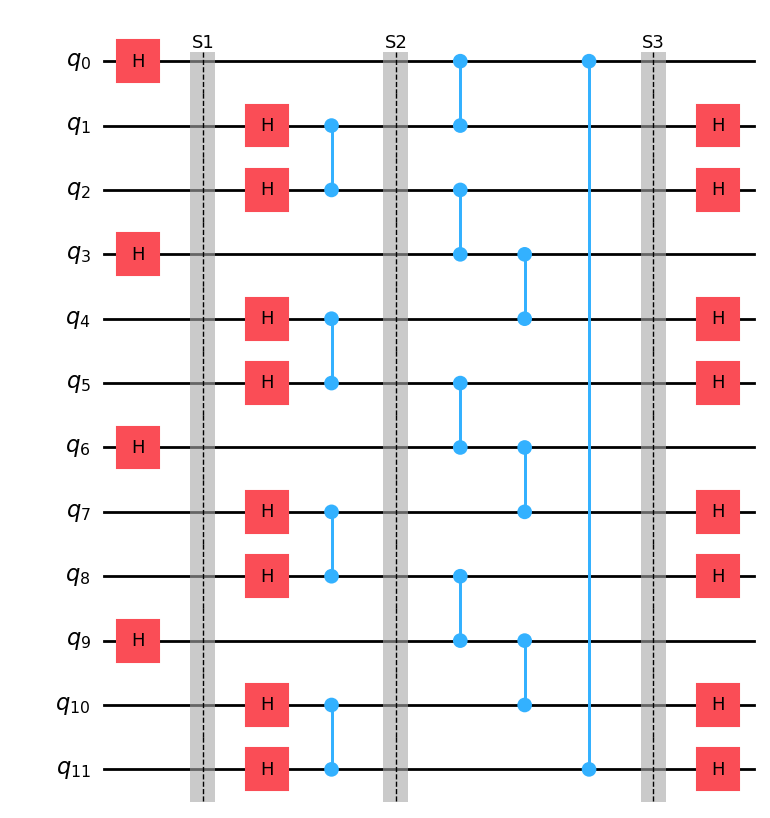

In [14]:
qc_C4.draw(output='mpl', fold=50, style='iqp')

#### L5

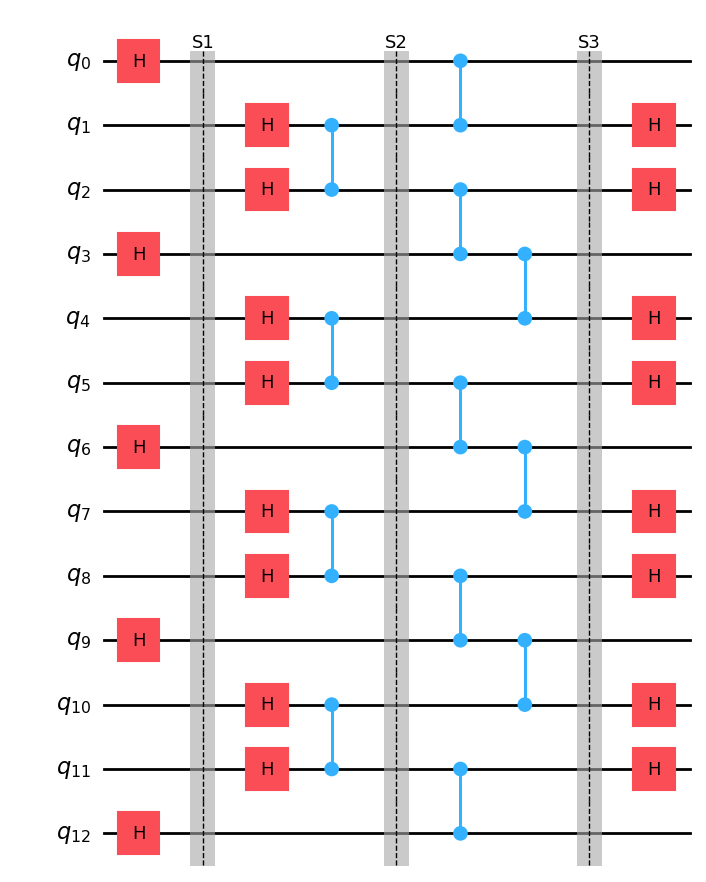

In [15]:
qc_L5.draw(output='mpl', fold=50, style='iqp')

#### K4

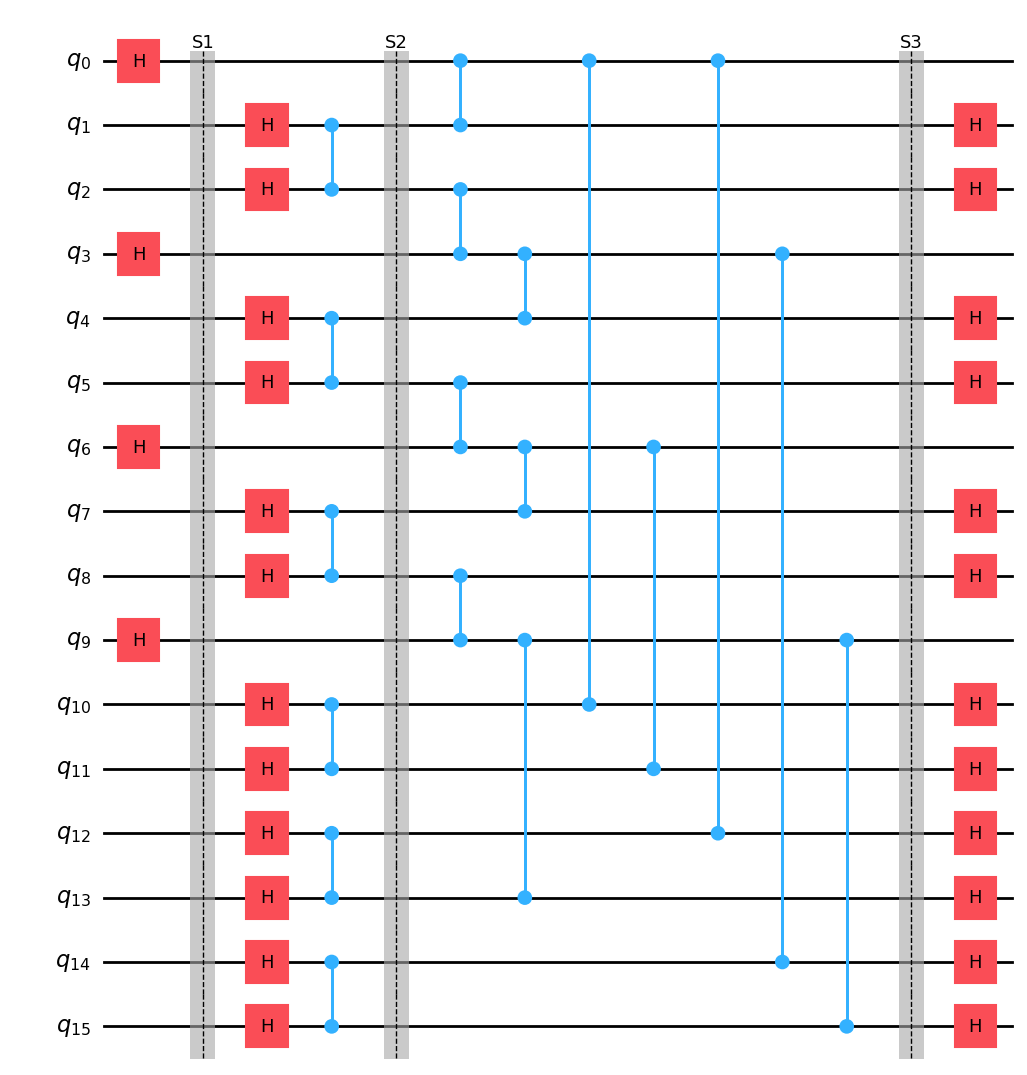

In [16]:
qc_K4.draw(output='mpl', fold=50, style='iqp')

#### C5

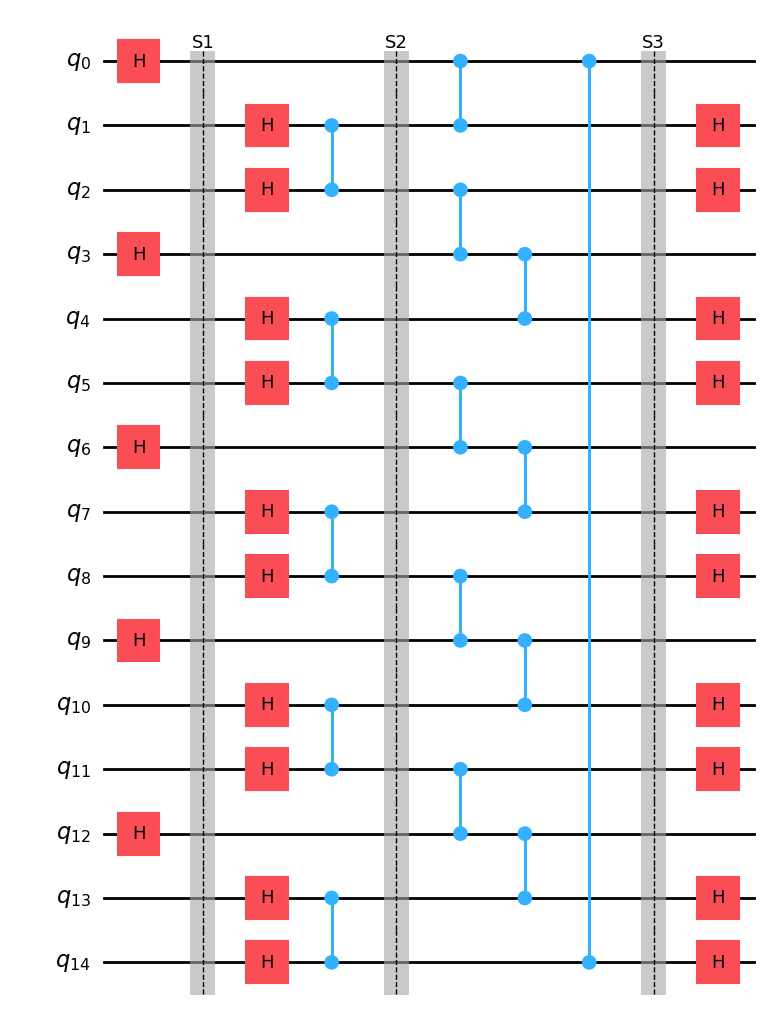

In [17]:
qc_C5.draw(output='mpl', fold=50, style='iqp')

#### K₁,₄

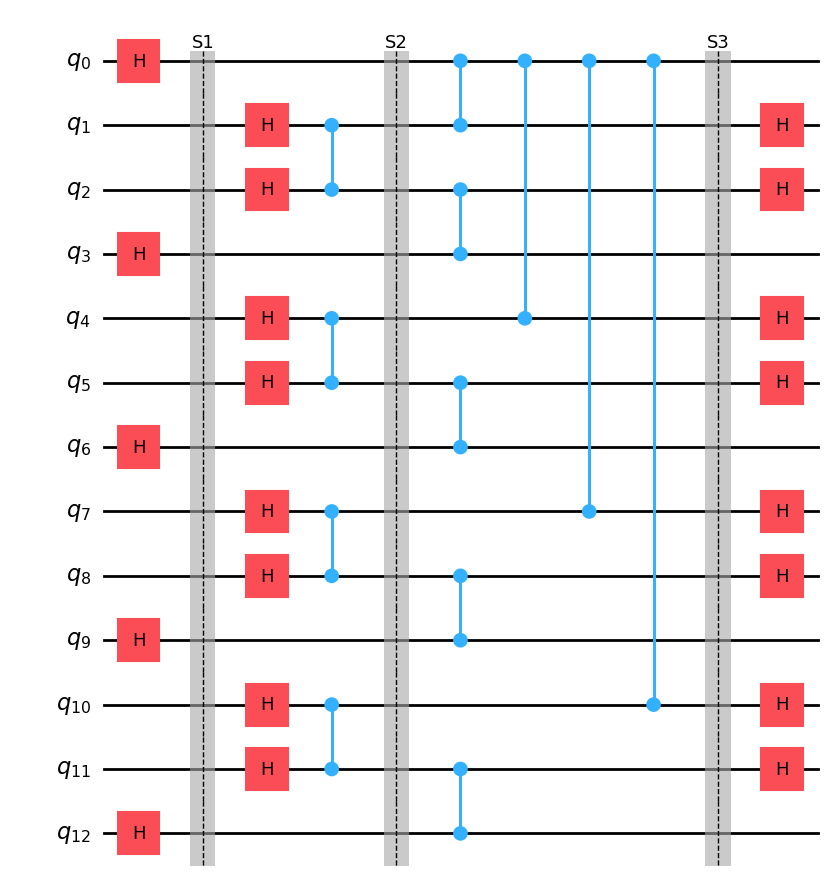

In [18]:
qc_K14.draw(output='mpl', fold=50, style='iqp')

#### Bull

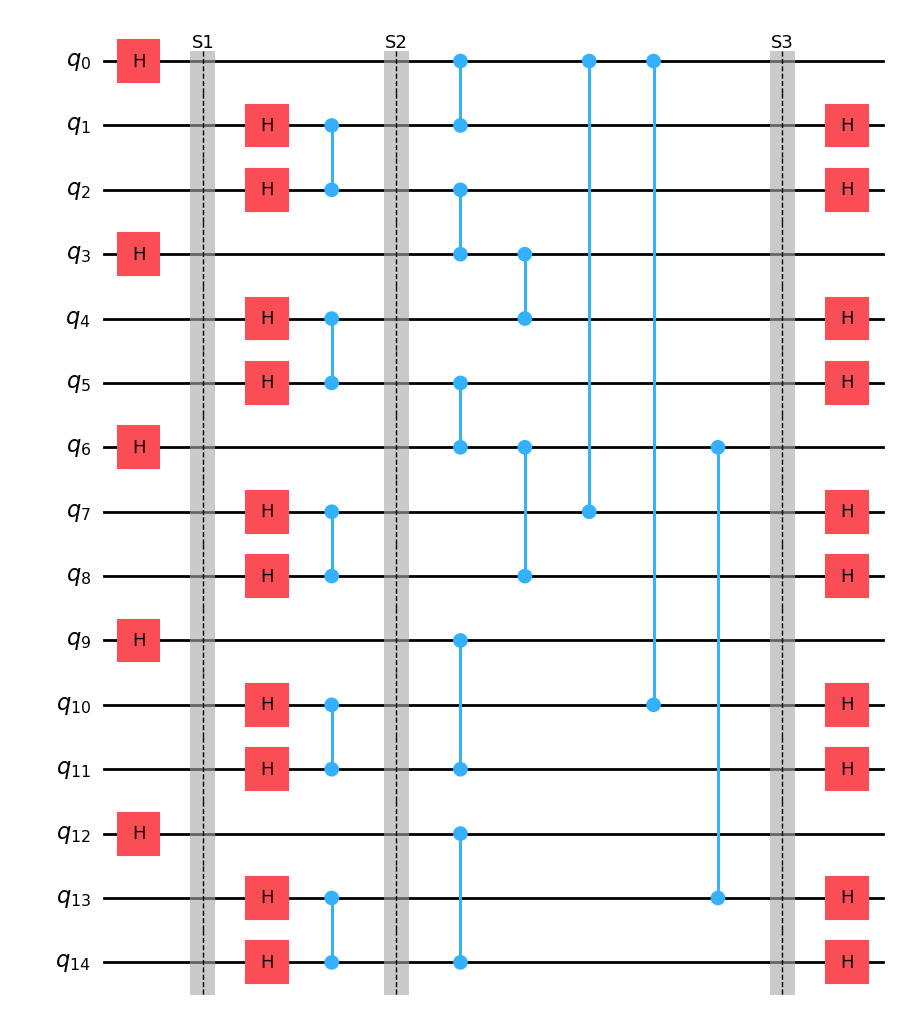

In [19]:
qc_Bull.draw(output='mpl', fold=50, style='iqp')

## 6. Correction Functions

All correction formulas verified at F = 1.0 for every measurement outcome.

| Protocol | Correction | Type |
|:--------:|:----------:|:----:|
| GHZ4     | A:I, B:Z^s1, C:Z^s3, D:X^{s2⊕s4⊕s6}·Z^s5 | Empirical (cyclic star) |
| L4       | A:I, B:X^s2, C:X^{s1⊕s4}, D:X^{s2⊕s3⊕s6}·Z^{s1⊕s4⊕s5} | Theorem 4.3 |
| C4       | A:I, B:I, C:X^{s1⊕s4}·Z^{s2⊕s3⊕s6⊕s7}, D:X^{s2⊕s7}·Z^{s1⊕s4⊕s5⊕s8} | Empirical (ring) |
| L5       | A:I, B:X^s2, C:X^{s1⊕s4}, D:X^{s2⊕s3⊕s6}, E:X^{s1⊕s4⊕s5⊕s8}·Z^{s2⊕s3⊕s6⊕s7} | Theorem 4.3 |
| K4       | All nodes: Z only (X cancels by symmetry) | Empirical (complete) |
| C5       | All nodes: Z only — Z^{far-side XOR} per node | Empirical (odd ring) |
| K₁,₄    | hub:Z^{...}, all leaves: X^{same}·Z^{near} | Theorem 4.3 extended |
| Bull     | N0:I, N1:I, N2:X^{s1⊕s4}, N3:X^{s1⊕s2⊕s4⊕s6⊕s8}·Z^s7, N4:X^{s3⊕s5⊕s10}·Z^{s1⊕s4⊕s9} | Empirical (mixed) |


In [20]:
def corrections_GHZ4(out):
    s1,s2,s3,s4,s5,s6 = out
    C = np.eye(16, dtype=complex)
    if s1:       C = gaten(Z,1,4) @ C
    if s3:       C = gaten(Z,2,4) @ C
    if s2^s4^s6: C = gaten(X,3,4) @ C
    if s5:       C = gaten(Z,3,4) @ C
    return C

def corrections_L4(out):
    s1,s2,s3,s4,s5,s6 = out
    C = np.eye(16, dtype=complex)
    if s2:       C = gaten(X,1,4) @ C
    if s1^s4:    C = gaten(X,2,4) @ C
    if s2^s3^s6: C = gaten(X,3,4) @ C
    if s1^s4^s5: C = gaten(Z,3,4) @ C
    return C

def corrections_C4(out):
    s1,s2,s3,s4,s5,s6,s7,s8 = out
    C = np.eye(16, dtype=complex)
    if s1^s4:           C = gaten(X,2,4) @ C
    if s2^s3^s6^s7:     C = gaten(Z,2,4) @ C
    if s2^s7:           C = gaten(X,3,4) @ C
    if s1^s4^s5^s8:     C = gaten(Z,3,4) @ C
    return C

def corrections_L5(out):
    s1,s2,s3,s4,s5,s6,s7,s8 = out
    C = np.eye(32, dtype=complex)
    if s2:             C = gaten(X,1,5) @ C
    if s1^s4:          C = gaten(X,2,5) @ C
    if s2^s3^s6:       C = gaten(X,3,5) @ C
    if s1^s4^s5^s8:    C = gaten(X,4,5) @ C
    if s2^s3^s6^s7:    C = gaten(Z,4,5) @ C
    return C

def corrections_K4(out):
    s = out  # s[0]=s1 ... s[11]=s12
    C = np.eye(16, dtype=complex)
    if s[1]^s[7]^s[9]:   C = gaten(Z,0,4) @ C  # N0: Z^{s2^s8^s10}
    if s[0]^s[3]^s[11]:  C = gaten(Z,1,4) @ C  # N1: Z^{s1^s4^s12}
    if s[2]^s[5]^s[6]:   C = gaten(Z,2,4) @ C  # N2: Z^{s3^s6^s7}
    if s[4]^s[8]^s[10]:  C = gaten(Z,3,4) @ C  # N3: Z^{s5^s9^s11}
    return C

def corrections_C5(out):
    s1,s2,s3,s4,s5,s6,s7,s8,s9,s10 = out
    C = np.eye(32, dtype=complex)
    if s2^s9:   C = gaten(Z,0,5) @ C  # A
    if s1^s4:   C = gaten(Z,1,5) @ C  # B
    if s3^s6:   C = gaten(Z,2,5) @ C  # C
    if s5^s8:   C = gaten(Z,3,5) @ C  # D
    if s7^s10:  C = gaten(Z,4,5) @ C  # E
    return C

def corrections_K14(out):
    s1,s2,s3,s4,s5,s6,s7,s8 = out
    C = np.eye(32, dtype=complex)
    shared_x = s2^s4^s6^s8
    if s2^s4^s6^s8:  C = gaten(Z,0,5) @ C   # hub Z
    if shared_x:     C = gaten(X,1,5) @ C   # L1 X
    if s1:           C = gaten(Z,1,5) @ C   # L1 Z
    if shared_x:     C = gaten(X,2,5) @ C   # L2 X
    if s3:           C = gaten(Z,2,5) @ C   # L2 Z
    if shared_x:     C = gaten(X,3,5) @ C   # L3 X
    if s5:           C = gaten(Z,3,5) @ C   # L3 Z
    if shared_x:     C = gaten(X,4,5) @ C   # L4 X
    if s7:           C = gaten(Z,4,5) @ C   # L4 Z
    return C

def corrections_Bull(out):
    s1,s2,s3,s4,s5,s6,s7,s8,s9,s10 = out
    C = np.eye(32, dtype=complex)
    if s1^s4:                  C = gaten(X,2,5) @ C  # N2 X
    if s1^s2^s4^s6^s8:        C = gaten(X,3,5) @ C  # N3 X
    if s7:                     C = gaten(Z,3,5) @ C  # N3 Z
    if s3^s5^s10:              C = gaten(X,4,5) @ C  # N4 X
    if s1^s4^s9:               C = gaten(Z,4,5) @ C  # N4 Z
    return C

CORRECTIONS = {
    'GHZ4': corrections_GHZ4,
    'L4':   corrections_L4,
    'C4':   corrections_C4,
    'L5':   corrections_L5,
    'K4':   corrections_K4,
    'C5':   corrections_C5,
    'K14':  corrections_K14,
    'Bull': corrections_Bull,
}
print('Correction functions defined for all 8 topologies.')

Correction functions defined for all 8 topologies.


## 7. Verification Infrastructure

In [21]:
# Protocol configs: circuit, resource qubits, data qubits, n_outcomes
CIRCUITS = {
    'GHZ4': build_GHZ4(), 'L4': build_L4(), 'C4': build_C4(),
    'L5':   build_L5(),   'K4': build_K4(), 'C5': build_C5(),
    'K14':  build_K14(),  'Bull': build_Bull(),
}

CONFIGS = {
    'GHZ4': dict(res=[1,2,4,5,7,8],             data=[0,3,6,9],     n_out=6),
    'L4':   dict(res=[1,2,4,5,7,8],             data=[0,3,6,9],     n_out=6),
    'C4':   dict(res=[1,2,4,5,7,8,10,11],       data=[0,3,6,9],     n_out=8),
    'L5':   dict(res=[1,2,4,5,7,8,10,11],       data=[0,3,6,9,12],  n_out=8),
    'K4':   dict(res=[1,2,4,5,7,8,10,11,12,13,14,15], data=[0,3,6,9], n_out=12),
    'C5':   dict(res=[1,2,4,5,7,8,10,11,13,14], data=[0,3,6,9,12],  n_out=10),
    'K14':  dict(res=[1,2,4,5,7,8,10,11],       data=[0,3,6,9,12],  n_out=8),
    'Bull': dict(res=[1,2,4,5,7,8,10,11,13,14], data=[0,3,6,9,12],  n_out=10),
}

def extract_data(sv_array, res, data, outcome):
    n_data = len(data)
    res_req = {res[k]: outcome[k] for k in range(len(res))}
    d = np.zeros(2**n_data, dtype=complex)
    for idx in range(len(sv_array)):
        amp = sv_array[idx]
        if abs(amp) < 1e-14: continue
        if not all((idx >> q) & 1 == v for q, v in res_req.items()): continue
        di = sum(((idx >> data[k]) & 1) << k for k in range(n_data))
        d[di] += amp
    norm = np.linalg.norm(d)
    return d / norm if norm > 1e-12 else None

def verify_protocol(name):
    cfg = CONFIGS[name]
    sv  = Statevector(CIRCUITS[name]).data
    t   = TARGETS[name].data
    corr_fn = CORRECTIONS[name]
    results = []; failures = []
    for outcome in iproduct([0,1], repeat=cfg['n_out']):
        d = extract_data(sv, cfg['res'], cfg['data'], outcome)
        if d is None: continue
        fid = float(np.real(abs(np.vdot(t, corr_fn(outcome) @ d)) ** 2))
        results.append((outcome, fid))
        if abs(fid - 1.0) > 1e-8: failures.append((outcome, fid))
    return results, failures

print('Helpers defined: extract_data, verify_protocol')

Helpers defined: extract_data, verify_protocol


## 8. Statevector Verification — All Outcomes

> **Note:** K4 has 4096 outcomes and 16 qubits — may take 30–60 seconds.

In [22]:
ALL_RESULTS = {}

print('=' * 60)
print('  STATEVECTOR VERIFICATION — ALL 8 TOPOLOGIES')
print('=' * 60)

for name in CONFIGS:
    results, failures = verify_protocol(name)
    ALL_RESULTS[name] = results
    fids = [f for _, f in results]
    total = 2 ** CONFIGS[name]['n_out']
    status = '✓  F = 1.0' if not failures else f'✗  {len(failures)} failures'
    print(f'  {name:6s}  {len(results):>5}/{total:<5}  '
          f'minF={min(fids):.10f}  {status}')

  STATEVECTOR VERIFICATION — ALL 8 TOPOLOGIES
  GHZ4       64/64     minF=1.0000000000  ✓  F = 1.0
  L4         64/64     minF=1.0000000000  ✓  F = 1.0
  C4        256/256    minF=1.0000000000  ✓  F = 1.0
  L5        256/256    minF=1.0000000000  ✓  F = 1.0
  K4       4096/4096   minF=1.0000000000  ✓  F = 1.0
  C5       1024/1024   minF=1.0000000000  ✓  F = 1.0
  K14       256/256    minF=1.0000000000  ✓  F = 1.0
  Bull     1024/1024   minF=1.0000000000  ✓  F = 1.0


## 9. Fidelity Bar Charts

Each chart shows F per measurement outcome. All bars should be at F = 1.0.

#### GHZ4

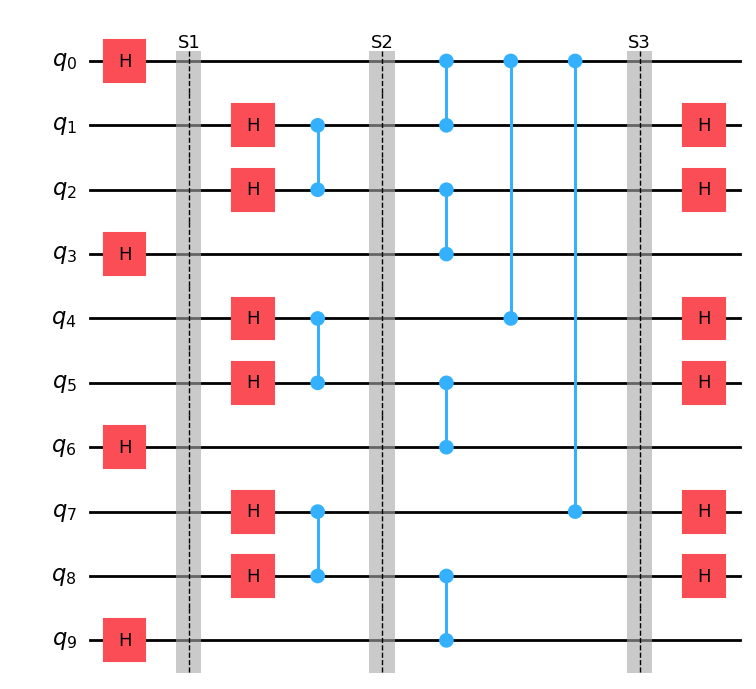

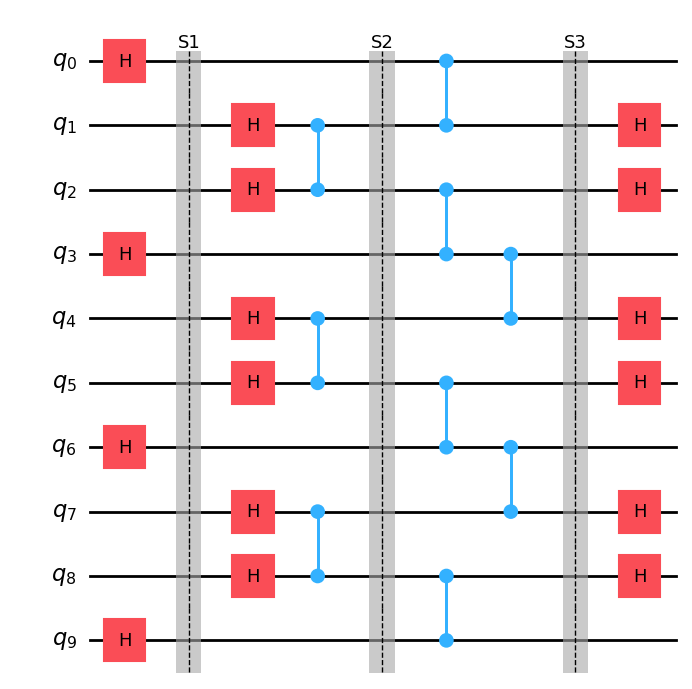

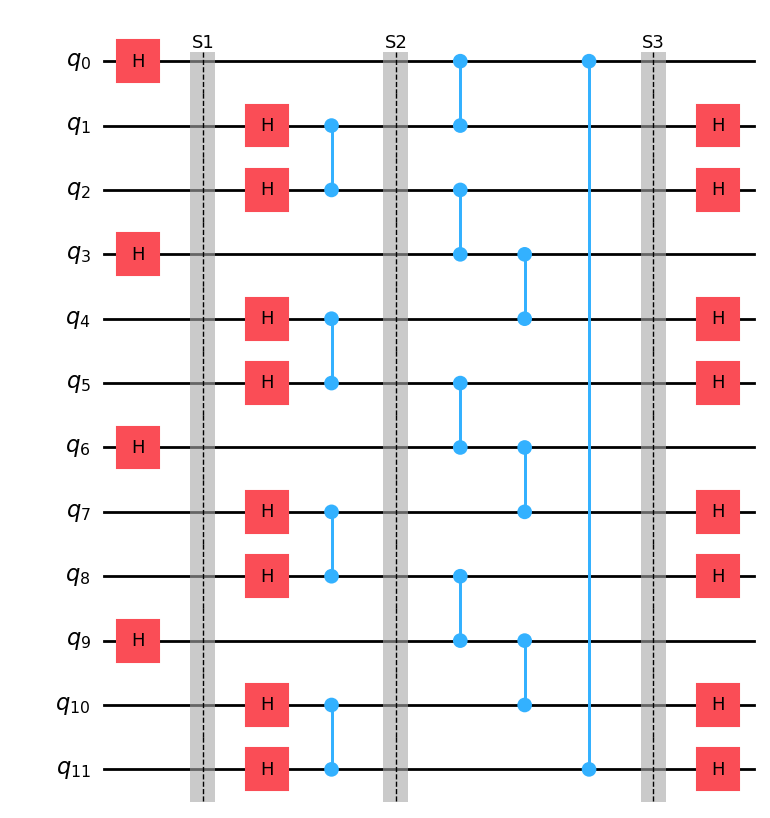

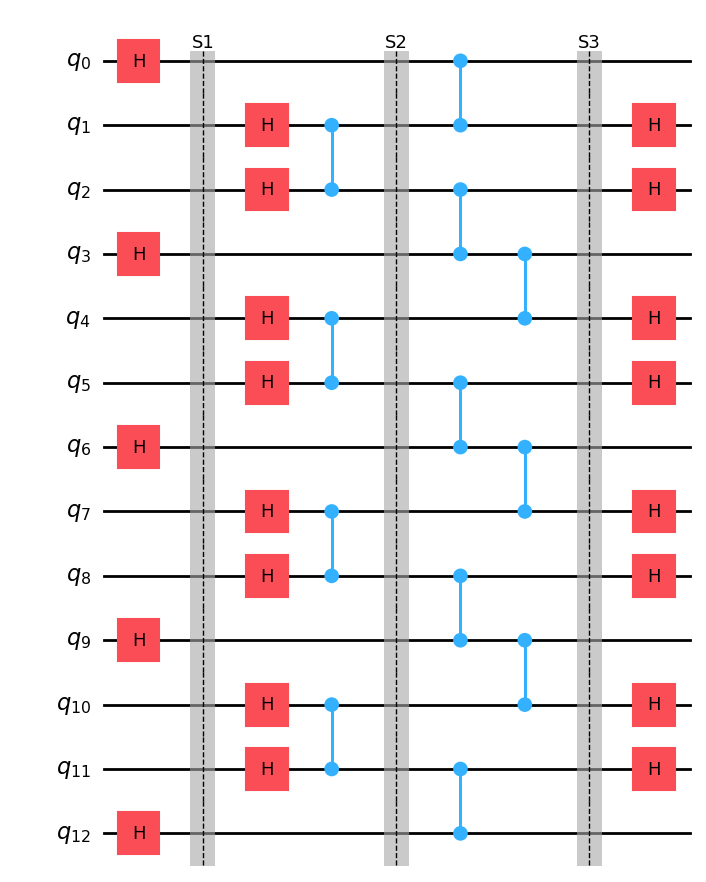

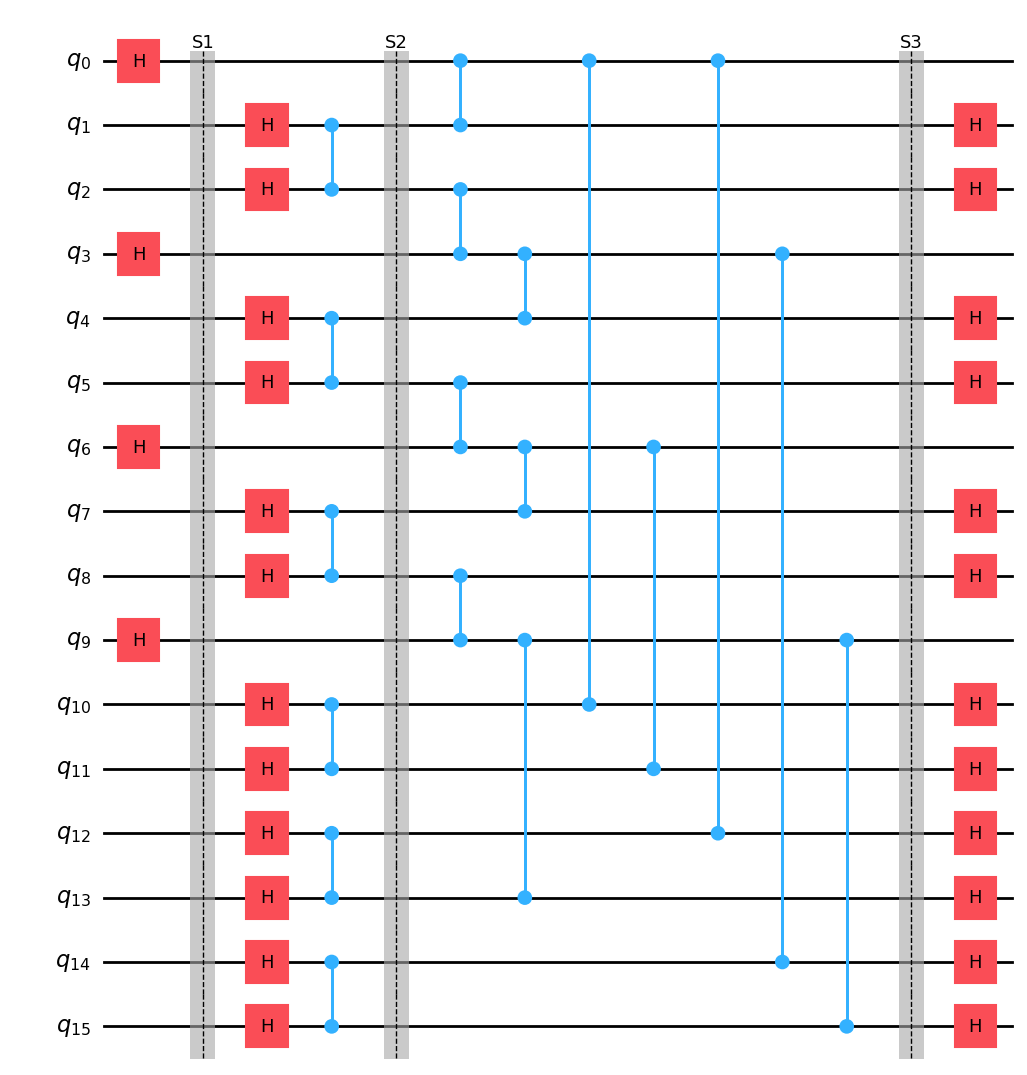

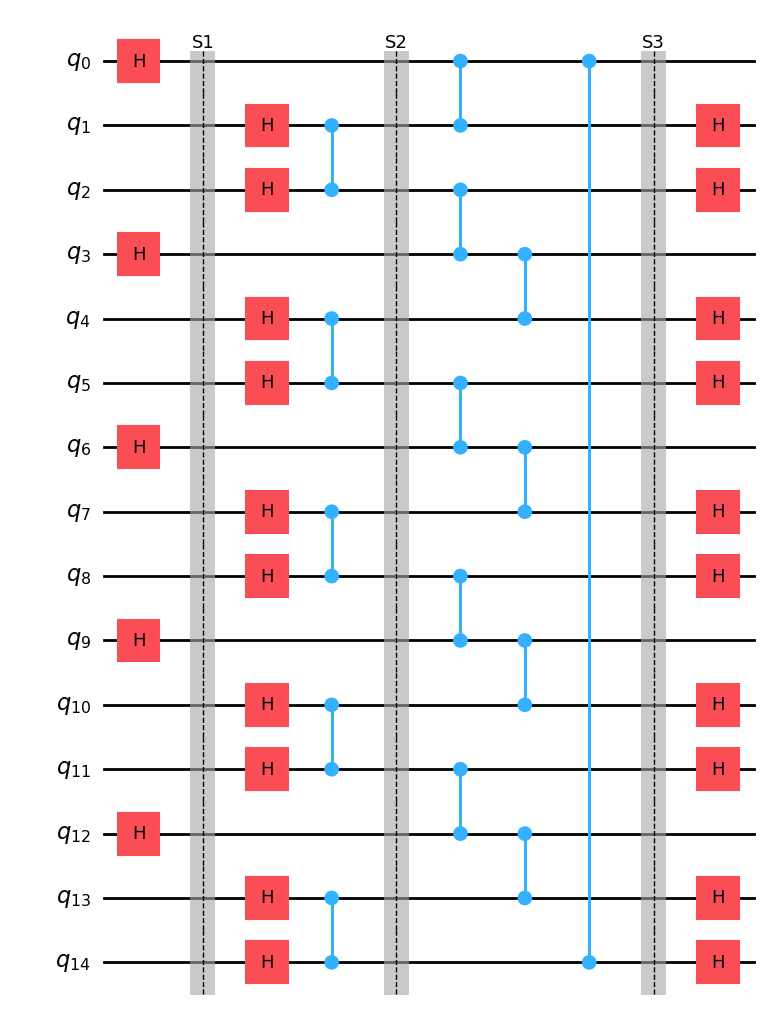

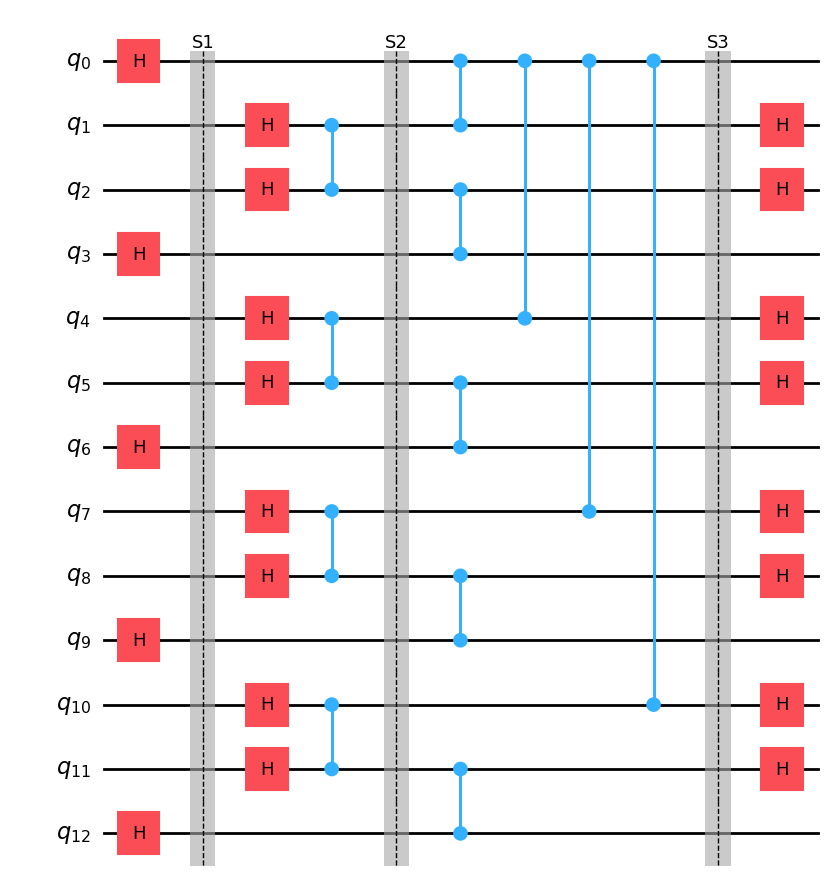

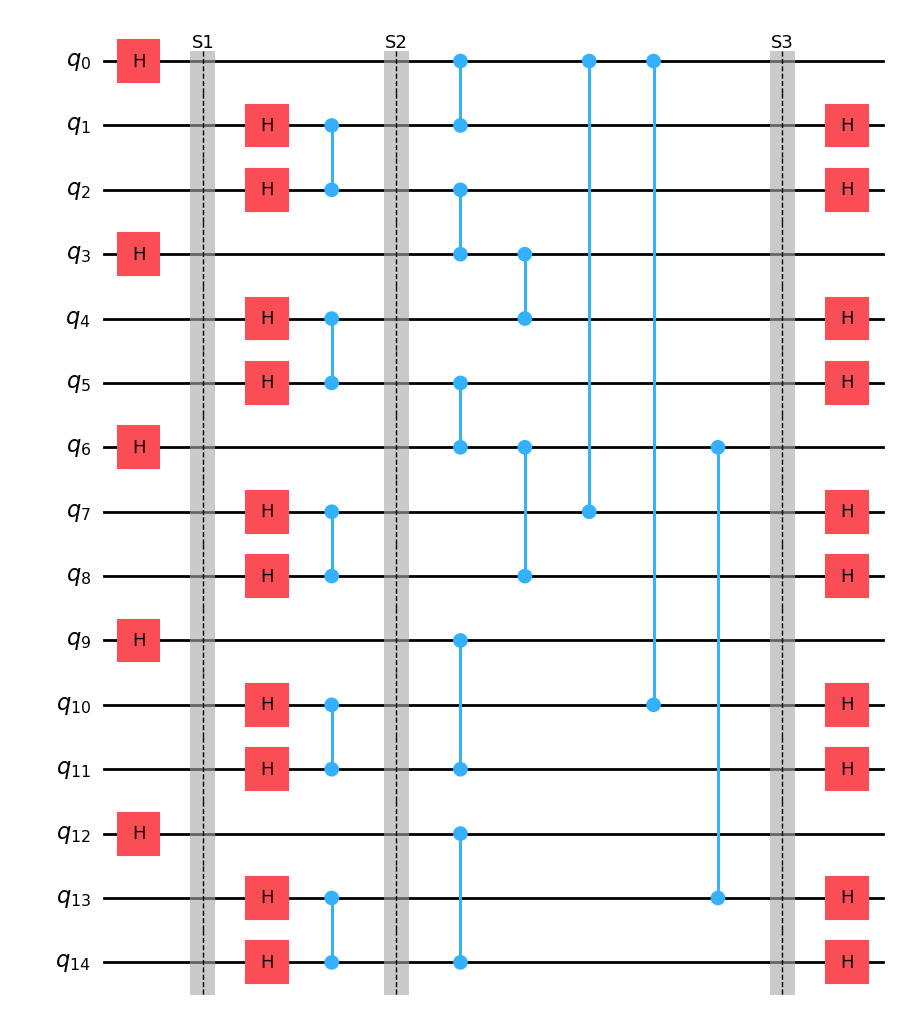

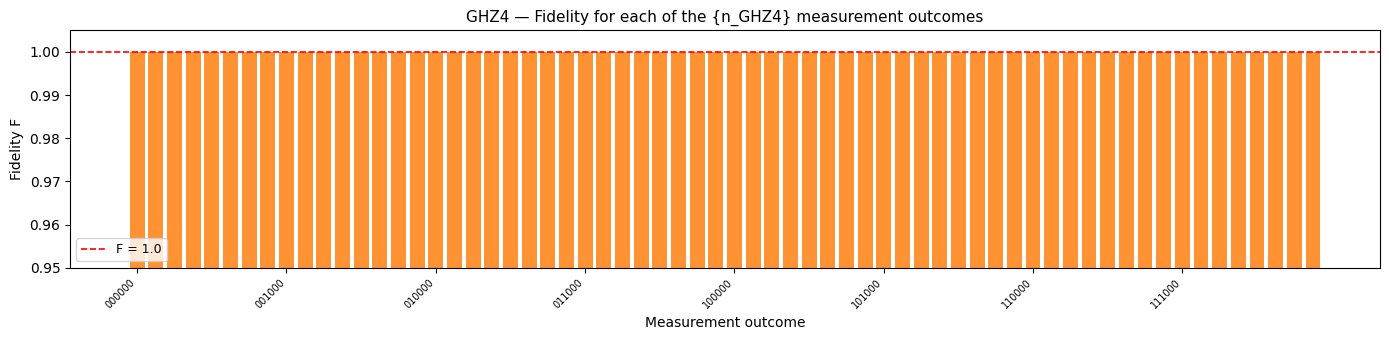

In [23]:
results_GHZ4 = ALL_RESULTS['GHZ4']
fids_GHZ4 = [f for _, f in results_GHZ4]
labels_GHZ4 = [''.join(map(str,o)) for o,_ in results_GHZ4]
n_GHZ4 = len(fids_GHZ4)
tick_step = max(1, n_GHZ4 // 8)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(n_GHZ4), fids_GHZ4, color='#ff7f0e', width=0.8, alpha=0.85)
ax.axhline(1.0, color='red', lw=1.2, ls='--', label='F = 1.0')
ax.set_ylim(0.95, 1.005)
ax.set_xlabel('Measurement outcome', fontsize=10)
ax.set_ylabel('Fidelity F', fontsize=10)
ax.set_title('GHZ4 — Fidelity for each of the {n_GHZ4} measurement outcomes', fontsize=11)
ax.set_xticks(range(0, n_GHZ4, tick_step))
ax.set_xticklabels([labels_GHZ4[i] for i in range(0, n_GHZ4, tick_step)], rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### L4

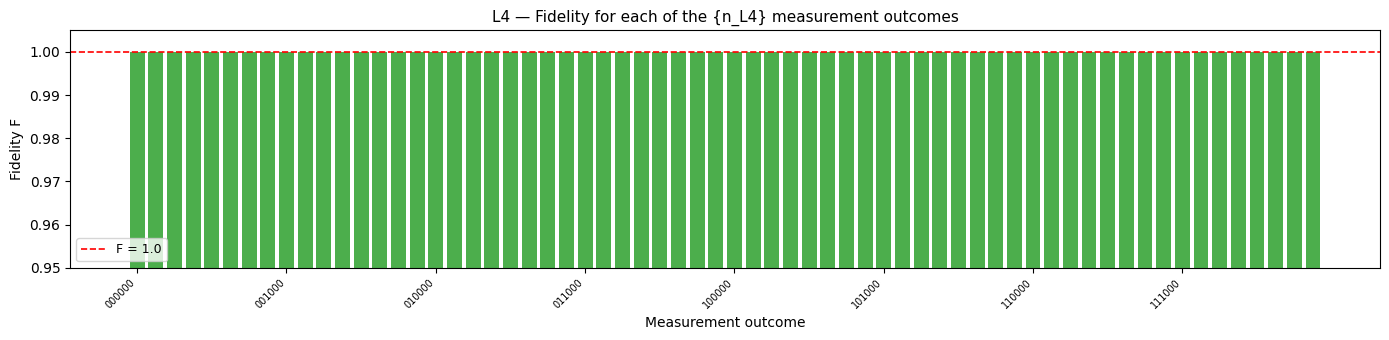

In [24]:
results_L4 = ALL_RESULTS['L4']
fids_L4 = [f for _, f in results_L4]
labels_L4 = [''.join(map(str,o)) for o,_ in results_L4]
n_L4 = len(fids_L4)
tick_step = max(1, n_L4 // 8)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(n_L4), fids_L4, color='#2ca02c', width=0.8, alpha=0.85)
ax.axhline(1.0, color='red', lw=1.2, ls='--', label='F = 1.0')
ax.set_ylim(0.95, 1.005)
ax.set_xlabel('Measurement outcome', fontsize=10)
ax.set_ylabel('Fidelity F', fontsize=10)
ax.set_title('L4 — Fidelity for each of the {n_L4} measurement outcomes', fontsize=11)
ax.set_xticks(range(0, n_L4, tick_step))
ax.set_xticklabels([labels_L4[i] for i in range(0, n_L4, tick_step)], rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### C4

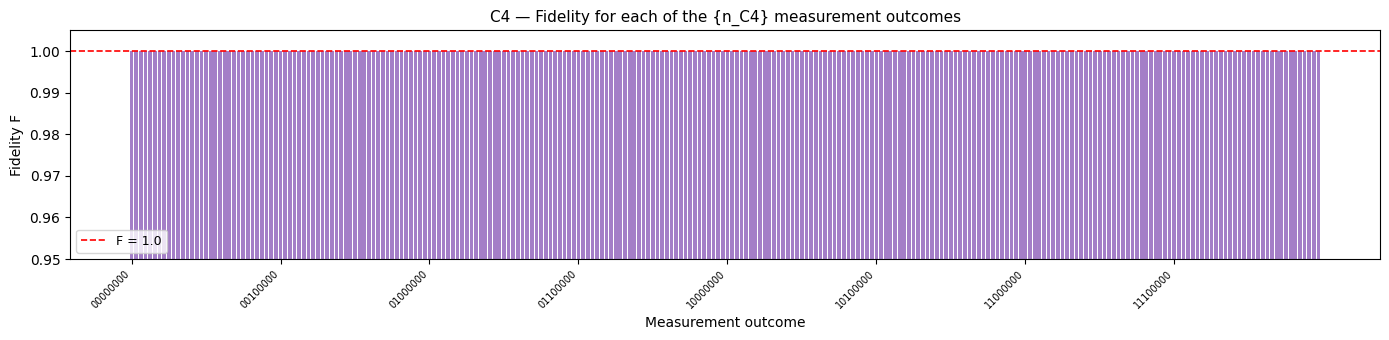

In [25]:
results_C4 = ALL_RESULTS['C4']
fids_C4 = [f for _, f in results_C4]
labels_C4 = [''.join(map(str,o)) for o,_ in results_C4]
n_C4 = len(fids_C4)
tick_step = max(1, n_C4 // 8)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(n_C4), fids_C4, color='#9467bd', width=0.8, alpha=0.85)
ax.axhline(1.0, color='red', lw=1.2, ls='--', label='F = 1.0')
ax.set_ylim(0.95, 1.005)
ax.set_xlabel('Measurement outcome', fontsize=10)
ax.set_ylabel('Fidelity F', fontsize=10)
ax.set_title('C4 — Fidelity for each of the {n_C4} measurement outcomes', fontsize=11)
ax.set_xticks(range(0, n_C4, tick_step))
ax.set_xticklabels([labels_C4[i] for i in range(0, n_C4, tick_step)], rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### L5

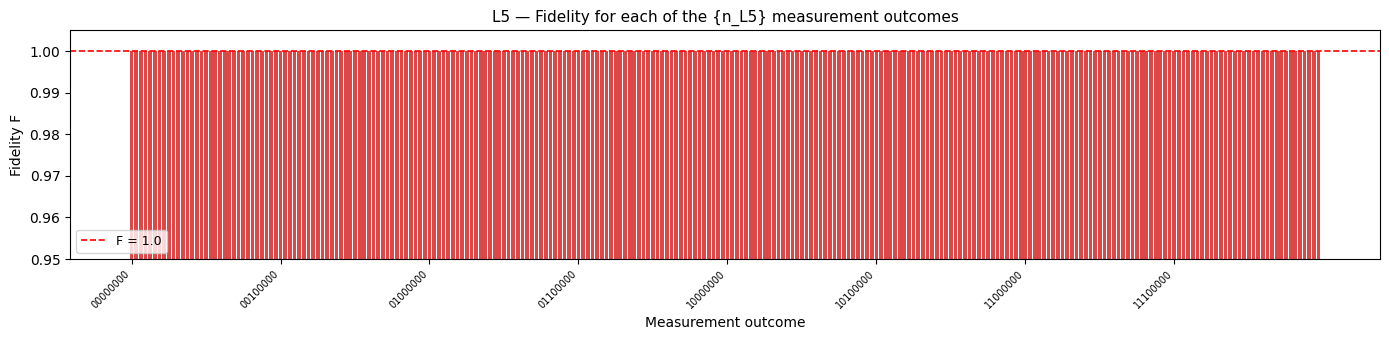

In [26]:
results_L5 = ALL_RESULTS['L5']
fids_L5 = [f for _, f in results_L5]
labels_L5 = [''.join(map(str,o)) for o,_ in results_L5]
n_L5 = len(fids_L5)
tick_step = max(1, n_L5 // 8)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(n_L5), fids_L5, color='#d62728', width=0.8, alpha=0.85)
ax.axhline(1.0, color='red', lw=1.2, ls='--', label='F = 1.0')
ax.set_ylim(0.95, 1.005)
ax.set_xlabel('Measurement outcome', fontsize=10)
ax.set_ylabel('Fidelity F', fontsize=10)
ax.set_title('L5 — Fidelity for each of the {n_L5} measurement outcomes', fontsize=11)
ax.set_xticks(range(0, n_L5, tick_step))
ax.set_xticklabels([labels_L5[i] for i in range(0, n_L5, tick_step)], rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### K4

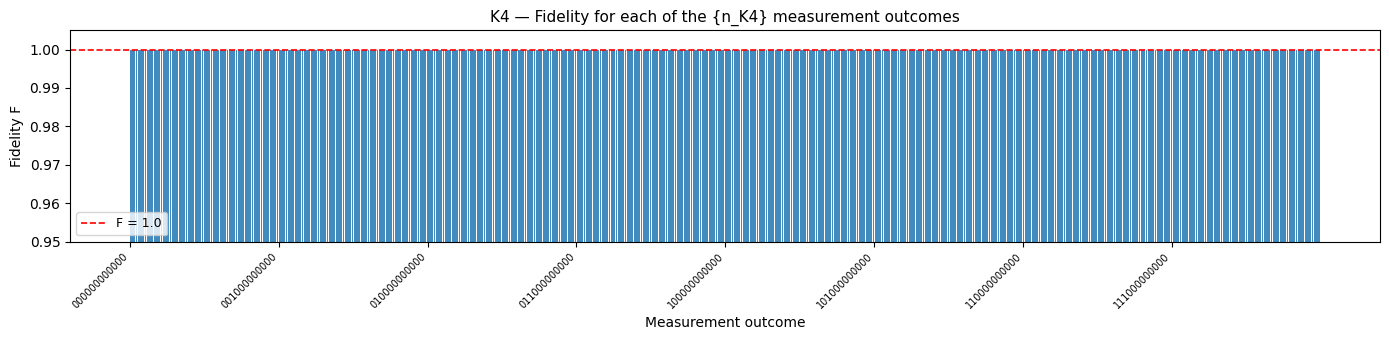

In [27]:
results_K4 = ALL_RESULTS['K4']
fids_K4 = [f for _, f in results_K4]
labels_K4 = [''.join(map(str,o)) for o,_ in results_K4]
n_K4 = len(fids_K4)
tick_step = max(1, n_K4 // 8)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(n_K4), fids_K4, color='#1f77b4', width=0.8, alpha=0.85)
ax.axhline(1.0, color='red', lw=1.2, ls='--', label='F = 1.0')
ax.set_ylim(0.95, 1.005)
ax.set_xlabel('Measurement outcome', fontsize=10)
ax.set_ylabel('Fidelity F', fontsize=10)
ax.set_title('K4 — Fidelity for each of the {n_K4} measurement outcomes', fontsize=11)
ax.set_xticks(range(0, n_K4, tick_step))
ax.set_xticklabels([labels_K4[i] for i in range(0, n_K4, tick_step)], rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### C5

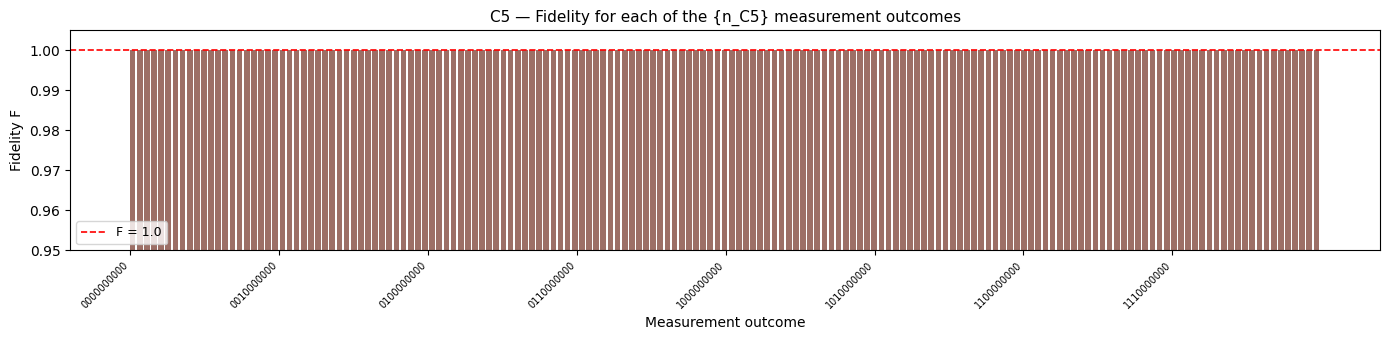

In [28]:
results_C5 = ALL_RESULTS['C5']
fids_C5 = [f for _, f in results_C5]
labels_C5 = [''.join(map(str,o)) for o,_ in results_C5]
n_C5 = len(fids_C5)
tick_step = max(1, n_C5 // 8)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(n_C5), fids_C5, color='#8c564b', width=0.8, alpha=0.85)
ax.axhline(1.0, color='red', lw=1.2, ls='--', label='F = 1.0')
ax.set_ylim(0.95, 1.005)
ax.set_xlabel('Measurement outcome', fontsize=10)
ax.set_ylabel('Fidelity F', fontsize=10)
ax.set_title('C5 — Fidelity for each of the {n_C5} measurement outcomes', fontsize=11)
ax.set_xticks(range(0, n_C5, tick_step))
ax.set_xticklabels([labels_C5[i] for i in range(0, n_C5, tick_step)], rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### K14

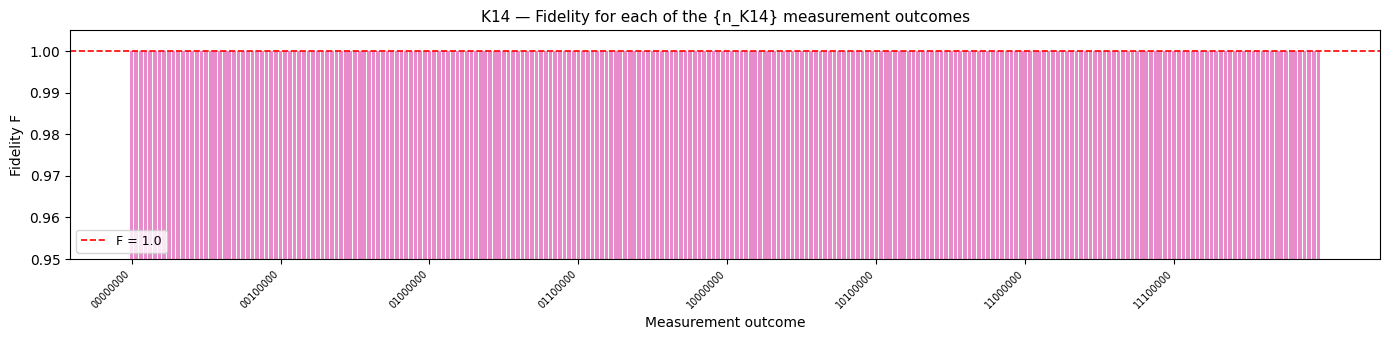

In [29]:
results_K14 = ALL_RESULTS['K14']
fids_K14 = [f for _, f in results_K14]
labels_K14 = [''.join(map(str,o)) for o,_ in results_K14]
n_K14 = len(fids_K14)
tick_step = max(1, n_K14 // 8)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(n_K14), fids_K14, color='#e377c2', width=0.8, alpha=0.85)
ax.axhline(1.0, color='red', lw=1.2, ls='--', label='F = 1.0')
ax.set_ylim(0.95, 1.005)
ax.set_xlabel('Measurement outcome', fontsize=10)
ax.set_ylabel('Fidelity F', fontsize=10)
ax.set_title('K14 — Fidelity for each of the {n_K14} measurement outcomes', fontsize=11)
ax.set_xticks(range(0, n_K14, tick_step))
ax.set_xticklabels([labels_K14[i] for i in range(0, n_K14, tick_step)], rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

#### Bull

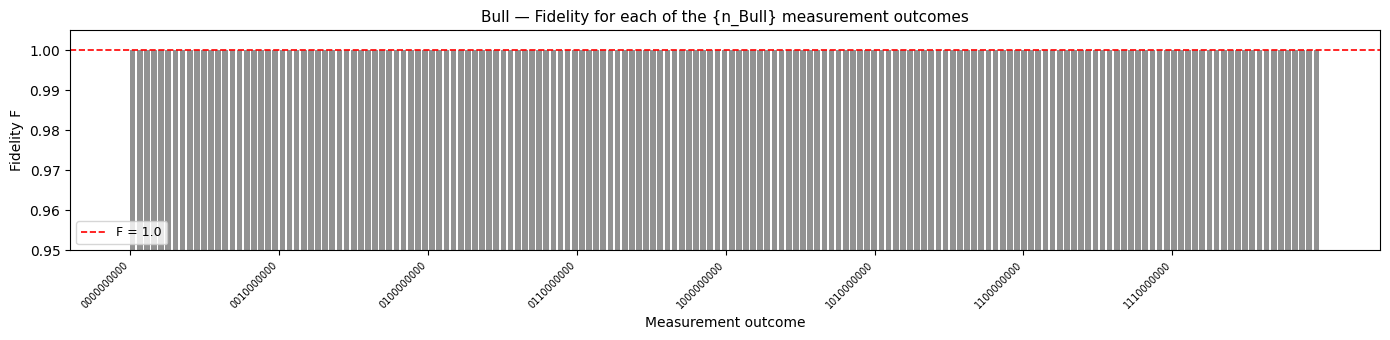

In [30]:
results_Bull = ALL_RESULTS['Bull']
fids_Bull = [f for _, f in results_Bull]
labels_Bull = [''.join(map(str,o)) for o,_ in results_Bull]
n_Bull = len(fids_Bull)
tick_step = max(1, n_Bull // 8)

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(range(n_Bull), fids_Bull, color='#7f7f7f', width=0.8, alpha=0.85)
ax.axhline(1.0, color='red', lw=1.2, ls='--', label='F = 1.0')
ax.set_ylim(0.95, 1.005)
ax.set_xlabel('Measurement outcome', fontsize=10)
ax.set_ylabel('Fidelity F', fontsize=10)
ax.set_title('Bull — Fidelity for each of the {n_Bull} measurement outcomes', fontsize=11)
ax.set_xticks(range(0, n_Bull, tick_step))
ax.set_xticklabels([labels_Bull[i] for i in range(0, n_Bull, tick_step)], rotation=45, ha='right', fontsize=7)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 10. Shot Simulation (8192 shots each)

Sample measurement outcomes from the exact probability distribution.
Expected mean fidelity = 1.0 for all protocols.

In [31]:
shots = 8192
rng   = np.random.default_rng(42)

print('=' * 60)
print(f'  SHOT SIMULATION  ({shots} shots per protocol)')
print('=' * 60)

for name in CONFIGS:
    cfg    = CONFIGS[name]
    sv     = Statevector(CIRCUITS[name]).data
    corr_fn = CORRECTIONS[name]
    results = ALL_RESULTS[name]
    outcomes = [o for o, _ in results]
    n_out_total = len(outcomes)

    # Outcome probabilities
    probs = np.zeros(n_out_total)
    for k, outcome in enumerate(outcomes):
        for idx in range(len(sv)):
            if all((idx >> cfg['res'][i]) & 1 == outcome[i] for i in range(cfg['n_out'])):
                probs[k] += abs(sv[idx]) ** 2
    probs /= probs.sum()

    fid_cache = {o: f for o, f in results}
    sampled   = rng.choice(n_out_total, size=shots, p=probs)
    shot_fids = np.array([fid_cache[outcomes[i]] for i in sampled])

    ok = abs(shot_fids.mean() - 1.0) < 1e-6
    print(f'  {name:6s}  mean F={shot_fids.mean():.10f}  '
          f'std={shot_fids.std():.1e}  {"✓" if ok else "✗"}')

  SHOT SIMULATION  (8192 shots per protocol)
  GHZ4    mean F=1.0000000000  std=2.2e-16  ✓
  L4      mean F=1.0000000000  std=2.2e-16  ✓
  C4      mean F=1.0000000000  std=2.2e-16  ✓
  L5      mean F=1.0000000000  std=3.3e-16  ✓
  K4      mean F=1.0000000000  std=2.2e-16  ✓
  C5      mean F=1.0000000000  std=3.3e-16  ✓
  K14     mean F=1.0000000000  std=3.3e-16  ✓
  Bull    mean F=1.0000000000  std=3.3e-16  ✓


## 11. Noisy Simulation

Exact noisy simulation for GHZ4, L4, C4 (main thesis protocols).
- Phase damping / Amplitude damping: exact Kraus sum (2^k combos)
- Depolarising: analytical $(1-3p/4)^k$

K4 is excluded (4^12 combos is intractable). L5, C5, K1,4, Bull use analytical formula.

In [32]:
# Numpy-based fast circuit runner for noisy simulation
_czm_cache = {}
def _cz(n, i, j, psi):
    k = (n,i,j)
    if k not in _czm_cache:
        idx = np.arange(2**n, dtype=np.int64)
        _czm_cache[k] = ((idx>>i)&1).astype(bool) & ((idx>>j)&1).astype(bool)
    out = psi.copy(); out[_czm_cache[k]] *= -1; return out

def _gate(G, q, n, psi):
    dl = 2**(n-q-1); dr = 2**q
    r = psi.reshape(dl, 2, dr)
    return np.tensordot(G, r, axes=([1],[1])).transpose(1,0,2).reshape(2**n)

def run_np(n, data_qs, res_pairs, walk_pairs, noise_ops=None):
    psi = np.zeros(2**n, dtype=complex); psi[0] = 1.0
    for q in data_qs: psi = _gate(H2, q, n, psi)
    flat_res = [q for q1,q2 in res_pairs for q in (q1,q2)]
    for q1,q2 in res_pairs:
        psi=_gate(H2,q1,n,psi); psi=_gate(H2,q2,n,psi); psi=_cz(n,q1,q2,psi)
    if noise_ops:
        for qi,K in zip(flat_res, noise_ops): psi=_gate(K,qi,n,psi)
    for di,ri in walk_pairs: psi=_cz(n,di,ri,psi)
    for q in flat_res: psi=_gate(H2,q,n,psi)
    return psi

def fstar_np(sv, target, res_qs, data_qs, corr_fn, n_out):
    n = int(np.log2(len(sv)))
    all_idx = np.arange(2**n, dtype=np.int64)
    oidx = sum(((all_idx>>res_qs[k])&1).astype(np.int64)<<k for k in range(len(res_qs)))
    p2d  = sum(((all_idx>>data_qs[k])&1).astype(np.int64)<<k for k in range(len(data_qs)))
    n_data = len(data_qs)
    F = 0.0
    for out_int in range(2**n_out):
        out = tuple((out_int>>k)&1 for k in range(n_out))
        mask=(oidx==out_int); s=sv[mask]; p=float(np.real(np.vdot(s,s)))
        if p<1e-16: continue
        s/=np.sqrt(p); d=np.zeros(2**n_data,dtype=complex)
        np.add.at(d,p2d[mask],s); d/=np.linalg.norm(d)
        F+=p*float(np.real(abs(np.vdot(target,corr_fn(out)@d))**2))
    return F

def kraus_pd(p): return [np.sqrt(1-p/2)*I2, np.sqrt(p/2)*Z]
def kraus_ad(p): return [np.array([[1,0],[0,np.sqrt(1-p)]],dtype=complex),
                          np.array([[0,np.sqrt(p)],[0,0]],dtype=complex)]

# Circuit params for numpy runner
NP_PARAMS = {
    'GHZ4': (10,[0,3,6,9],[(1,2),(4,5),(7,8)],[(0,1),(3,2),(0,4),(6,5),(0,7),(9,8)]),
    'L4':   (10,[0,3,6,9],[(1,2),(4,5),(7,8)],[(0,1),(3,2),(3,4),(6,5),(6,7),(9,8)]),
    'C4':   (12,[0,3,6,9],[(1,2),(4,5),(7,8),(10,11)],
             [(0,1),(3,2),(3,4),(6,5),(6,7),(9,8),(9,10),(0,11)]),
}

def compute_noisy(name, kfn, p):
    if p == 0: return 1.0
    nn, dq, rp, wp = NP_PARAMS[name]
    ops = kfn(p)
    n_rq = sum(2 for _ in rp)
    F = 0.0
    for combo in iproduct(range(2), repeat=n_rq):
        sv = run_np(nn, dq, rp, wp, [ops[k] for k in combo])
        cfg = CONFIGS[name]
        F += fstar_np(sv, TARGETS[name].data, cfg['res'], cfg['data'],
                     CORRECTIONS[name], cfg['n_out'])
    return float(F)

print('Noisy simulation helpers defined.')

Noisy simulation helpers defined.


In [33]:
p_vals = np.array([0, .05, .10, .15, .20, .25, .30, .35, .40, .45, .50])
noisy = {}

for channel, kfn, key in [('Phase damping', kraus_pd,'pd'),('Amplitude damping',kraus_ad,'ad')]:
    print(f'\n{channel}...')
    for name in ['GHZ4','L4','C4']:
        vals = []
        print(f'  {name}:', flush=True)
        for p in p_vals:
            f = compute_noisy(name, kfn, p); vals.append(f)
            print(f'    p={p:.2f}  F*={f:.6f}', flush=True)
        noisy.setdefault(name,{})[key] = np.array(vals)

# Depolarising: analytical
res_counts = {'GHZ4':6,'L4':6,'C4':8,'L5':8,'K4':12,'C5':10,'K14':8,'Bull':10}
for name in noisy:
    k = res_counts[name]
    noisy[name]['dep'] = (1 - 3*p_vals/4)**k
print('\nDone.')


Phase damping...
  GHZ4:
    p=0.00  F*=1.000000
    p=0.05  F*=0.860763
    p=0.10  F*=0.741201
    p=0.15  F*=0.638752
    p=0.20  F*=0.551124
    p=0.25  F*=0.476273
    p=0.30  F*=0.412385
    p=0.35  F*=0.357861
    p=0.40  F*=0.311296
    p=0.45  F*=0.271465
    p=0.50  F*=0.237305
  L4:
    p=0.00  F*=1.000000
    p=0.05  F*=0.860198
    p=0.10  F*=0.739170
    p=0.15  F*=0.634661
    p=0.20  F*=0.544644
    p=0.25  F*=0.467300
    p=0.30  F*=0.401006
    p=0.35  F*=0.344312
    p=0.40  F*=0.295936
    p=0.45  F*=0.254741
    p=0.50  F*=0.219727
  C4:
    p=0.00  F*=1.000000
    p=0.05  F*=0.818802
    p=0.10  F*=0.670802
    p=0.15  F*=0.550195
    p=0.20  F*=0.452122
    p=0.25  F*=0.372529
    p=0.30  F*=0.308053
    p=0.35  F*=0.255911
    p=0.40  F*=0.213814
    p=0.45  F*=0.179883
    p=0.50  F*=0.152588

Amplitude damping...
  GHZ4:
    p=0.00  F*=1.000000
    p=0.05  F*=0.859101
    p=0.10  F*=0.735336
    p=0.15  F*=0.627164
    p=0.20  F*=0.533124
    p=0.25  F*=0.451

### F*(p) per Protocol

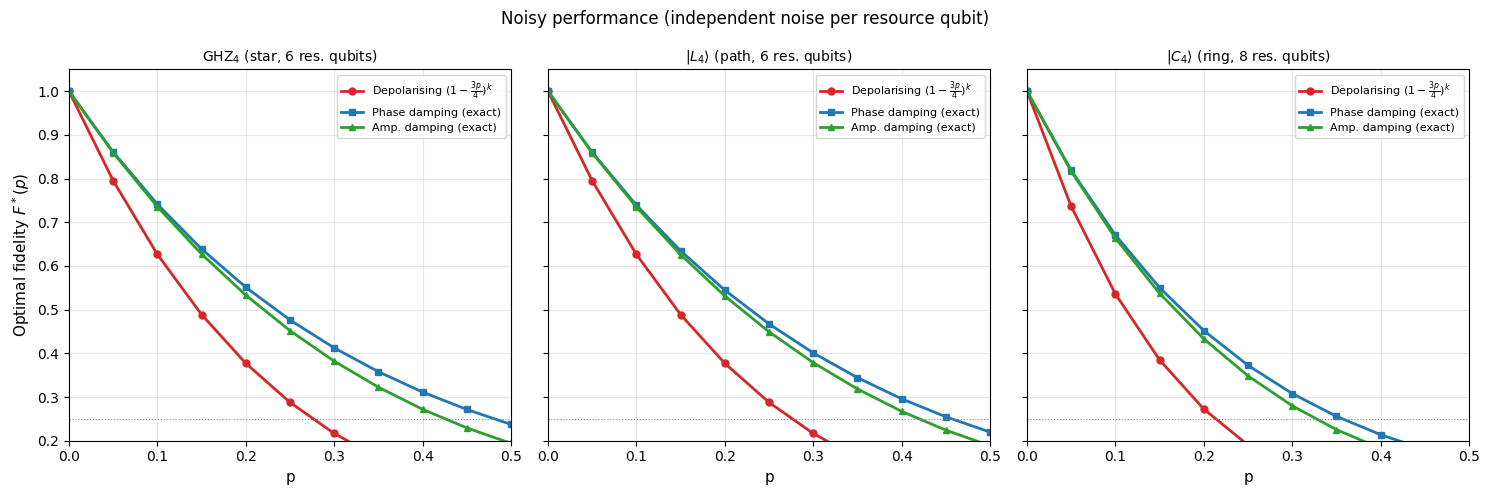

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
titles = {'GHZ4':r'GHZ$_4$ (star, 6 res. qubits)',
          'L4':  r'$|L_4\rangle$ (path, 6 res. qubits)',
          'C4':  r'$|C_4\rangle$ (ring, 8 res. qubits)'}

for ax, name in zip(axes, ['GHZ4','L4','C4']):
    res = noisy[name]
    ax.plot(p_vals, res['dep'], '#d62728', marker='o', ms=5, lw=2,
            label=r'Depolarising $(1-\frac{3p}{4})^k$')
    ax.plot(p_vals, res['pd'],  '#1f77b4', marker='s', ms=5, lw=2,
            label='Phase damping (exact)')
    ax.plot(p_vals, res['ad'],  '#2ca02c', marker='^', ms=5, lw=2,
            label='Amp. damping (exact)')
    ax.axhline(0.25, color='gray', lw=0.8, ls=':')
    ax.set_title(titles[name], fontsize=10)
    ax.set_xlabel('p', fontsize=11); ax.grid(True, alpha=0.3)
    ax.set_xlim(0,0.5); ax.set_ylim(0.20,1.05)
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel('Optimal fidelity $F^*(p)$', fontsize=11)
fig.suptitle('Noisy performance (independent noise per resource qubit)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_noisy_main.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Comparison Figure — All 4-Qubit Protocols

Fair comparison: GHZ₄, |L₄⟩, |C₄⟩ all produce 4-qubit output states
and are distributed via the same phase walk architecture.
GHZ₄ and |L₄⟩ are LC-inequivalent but use identical resources (6 qubits).
|C₄⟩ requires 2 extra resource qubits (4-edge ring).

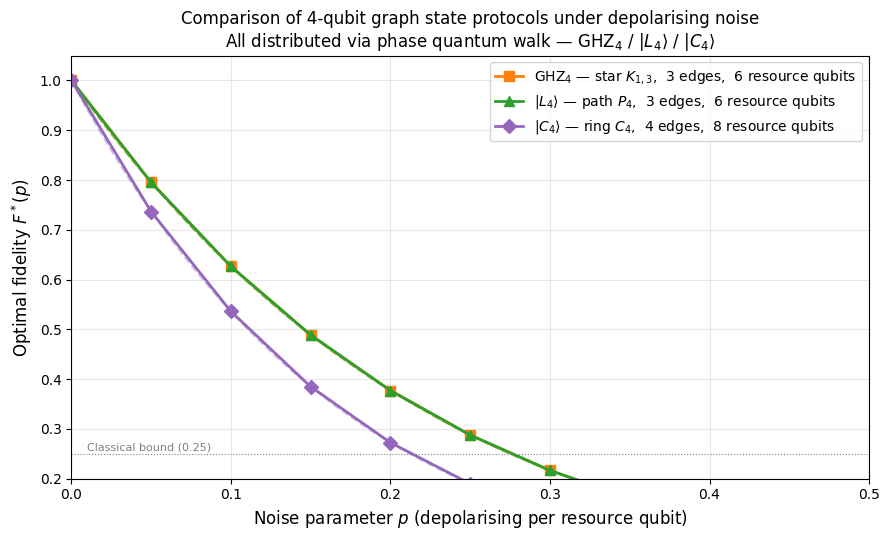

Saved fig_comparison_4qubit.png


In [35]:
p_fine = np.linspace(0, 0.5, 300)

fig, ax = plt.subplots(figsize=(9, 5.5))

# Analytical dashed reference lines
for k, col in [(6,'#ff7f0e'),(6,'#2ca02c'),(8,'#9467bd')]:
    ax.plot(p_fine, (1-3*p_fine/4)**k, col, lw=1.5, ls='--', alpha=0.4)

# Simulated curves
ax.plot(p_vals, noisy['GHZ4']['dep'], '#ff7f0e', marker='s', ms=7, lw=2,
        label=r'GHZ$_4$ — star $K_{1,3}$,  3 edges,  6 resource qubits')
ax.plot(p_vals, noisy['L4']['dep'],   '#2ca02c', marker='^', ms=7, lw=2,
        label=r'$|L_4\rangle$ — path $P_4$,  3 edges,  6 resource qubits')
ax.plot(p_vals, noisy['C4']['dep'],   '#9467bd', marker='D', ms=7, lw=2,
        label=r'$|C_4\rangle$ — ring $C_4$,  4 edges,  8 resource qubits')

ax.axhline(0.25, color='gray', lw=0.8, ls=':')
ax.text(0.01, 0.256, 'Classical bound (0.25)', fontsize=8, color='gray')
ax.set_xlabel('Noise parameter $p$ (depolarising per resource qubit)', fontsize=12)
ax.set_ylabel('Optimal fidelity $F^*(p)$', fontsize=12)
ax.set_title('Comparison of 4-qubit graph state protocols under depolarising noise\n'
             r'All distributed via phase quantum walk — GHZ$_4$ / $|L_4\rangle$ / $|C_4\rangle$',
             fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(0, 0.5); ax.set_ylim(0.20, 1.05); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_comparison_4qubit.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved fig_comparison_4qubit.png')

## 13. Summary

In [36]:
print('=' * 65)
print('  PHASE QUANTUM WALK — COMPLETE VERIFICATION SUMMARY')
print('=' * 65)
print(f'  {"Protocol":<8} {"Graph":<16} {"Outcomes":>9} {"Min F":>14} {"Result"}')
print('  ' + '-'*63)
for name in CONFIGS:
    results = ALL_RESULTS[name]
    fids = [f for _,f in results]
    total = 2**CONFIGS[name]['n_out']
    ok = all(abs(f-1.0)<1e-8 for f in fids)
    graph_desc = {
        'GHZ4':'Star K1,3','L4':'Path P4','C4':'Ring C4',
        'L5':'Path P5','K4':'Complete K4','C5':'Ring C5',
        'K14':'Star K1,4','Bull':'Bull graph'
    }
    print(f'  {name:<8} {graph_desc[name]:<16} {len(results):>5}/{total:<5}'
          f'  {min(fids):.12f}  {"✓ F=1.0" if ok else "✗"}')

print('\n  Structural observations:')
print('    Cycle graphs (C4, C5)     : only Z corrections — no X corrections')
print('    Star graphs (K1,3, K1,4)  : all leaves share the same X-parity term')
print('    Complete K4               : only Z corrections — X cancels by 3-regularity')
print('    Tree graphs (P4, P5, K1,k): Theorem 4.3 (path/star formula) applies directly')
print('    Mixed (Bull)              : longest correction strings at junction nodes')

  PHASE QUANTUM WALK — COMPLETE VERIFICATION SUMMARY
  Protocol Graph             Outcomes          Min F Result
  ---------------------------------------------------------------
  GHZ4     Star K1,3           64/64     1.000000000000  ✓ F=1.0
  L4       Path P4             64/64     1.000000000000  ✓ F=1.0
  C4       Ring C4            256/256    1.000000000000  ✓ F=1.0
  L5       Path P5            256/256    1.000000000000  ✓ F=1.0
  K4       Complete K4       4096/4096   1.000000000000  ✓ F=1.0
  C5       Ring C5           1024/1024   1.000000000000  ✓ F=1.0
  K14      Star K1,4          256/256    1.000000000000  ✓ F=1.0
  Bull     Bull graph        1024/1024   1.000000000000  ✓ F=1.0

  Structural observations:
    Cycle graphs (C4, C5)     : only Z corrections — no X corrections
    Star graphs (K1,3, K1,4)  : all leaves share the same X-parity term
    Complete K4               : only Z corrections — X cancels by 3-regularity
    Tree graphs (P4, P5, K1,k): Theorem 4.3 (path/st